# Downloading and pre-processing census data

Open your browser and navigate to National Historical Geographic Information System (NHGIS) at `https://www.nhgis.org/`. NHGIS provides normalized Census data across survey years and is generally easier to navigate than the US Census Bureau's website. Click to search for data, and then set the geographic level to `Block Group` and the year to the most recent ACS 5-year period (e.g. 2020-2024). Then set the topic to `Income - Household and Family Income` and `Race, Ethnicity and Origins - Hispanic Origin`. Make sure the Topic selector is set to `OR` and not `AND`. 

![Screenshot of NHGIS data selection interface with the specified settings](./images/nhgis_search_categories.png)

Navigate to the `GIS Files` tab, and select the Block Group level data for New York State. Proceed with the wizard, selecting CSV as the output format. After a brief period, both the tabular and spatial data will be available for download- download both files and save them to your data directory.

![Screenshot of NHGIS data download interface with the specified settings](./images/nhgis_status.png)

After unzipping the downloaded files, you'll notice a range of files with different extensions in each folder. Let's import both datesets using `pandas` and `geopandas` to see what they look like. 

In [3]:
import pandas as pd
import geopandas as gpd

census_data = pd.read_csv("./Data/nhgis0080_csv/nhgis0080_ds272_20245_blck_grp.csv")
census_geo = gpd.read_file(
    "./Data/nhgis0080_shape/nhgis0080_shapefile_tl2024_360_blck_grp_2024/NY_blck_grp_2024.shp"
)

We can inspect each dataset now to see what they look like using the `head()` method.

In [4]:
census_data.head()

,GISJOIN,YEAR,STUSAB,REGIONA,DIVISIONA,STATE,STATEA,COUNTY,COUNTYA,COUSUBA,...,AURTM008,AURTM009,AURTM010,AURTM011,AURTM012,AURTM013,AURTM014,AURTM015,AURTM016,AURTM017
0,G36000100001001,2020-2024,NY,NaN,NaN,New York,36,Albany County,1,NaN,...,9,14,52,63,13,60,43,59,12,14
1,G36000100001002,2020-2024,NY,NaN,NaN,New York,36,Albany County,1,NaN,...,14,50,14,67,14,54,41,14,14,44
2,G36000100002011,2020-2024,NY,NaN,NaN,New York,36,Albany County,1,NaN,...,41,79,14,32,14,23,14,14,14,23
3,G36000100002012,2020-2024,NY,NaN,NaN,New York,36,Albany County,1,NaN,...,4,72,14,14,61,98,14,68,165,14
4,G36000100002013,2020-2024,NY,NaN,NaN,New York,36,Albany County,1,NaN,...,14,14,14,14,68,70,23,31,28,97


In [5]:
census_geo.head()

,GISJOIN,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,GEOIDFQ,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,Shape_Area,geometry
0,G36000100001001,36,001,000100,1,360010001001,1500000US360010001001,Block Group 1,G5030,S,2010584.0,245021.0,+42.6637545,-073.7369092,8111.942345,2.255602e+06,"POLYGON ((1797365.008 791326.793, 1797589.244 ..."
1,G36000100001002,36,001,000100,2,360010001002,1500000US360010001002,Block Group 2,G5030,S,356872.0,0.0,+42.6739886,-073.7409837,2347.593407,3.568714e+05,"POLYGON ((1796699.07 790640.03, 1796684.412 79..."
2,G36000100002011,36,001,000201,1,360010002011,1500000US360010002011,Block Group 1,G5030,S,206621.0,0.0,+42.6600676,-073.7544079,2558.012713,2.066206e+05,"POLYGON ((1796729.693 789034.918, 1796727.453 ..."
3,G36000100002012,36,001,000201,2,360010002012,1500000US360010002012,Block Group 2,G5030,S,216941.0,0.0,+42.6584451,-073.7554372,2753.203326,2.169417e+05,"POLYGON ((1796745.89 788804.725, 1796768.361 7..."
4,G36000100002013,36,001,000201,3,360010002013,1500000US360010002013,Block Group 3,G5030,S,192305.0,0.0,+42.6564868,-073.7557630,2642.135683,1.923066e+05,"POLYGON ((1796772.743 788585.346, 1796777.727 ..."


We can see that the tabular data contains 116 columns, including several identifier and metadata columns, as well as the columns containing the data we selected for download. The spatial data contains fewer columns, but importantly contains a `geometry` column that contains the spatial information for each block group as well as a matching `GISJOIN` column that we can use to combine the datasets together. Let's do that now.

In [6]:
census_data_merged = census_geo.merge(census_data, on="GISJOIN", how="inner").set_index(
    "GISJOIN"
)

In [7]:
census_data_merged

,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,GEOIDFQ,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,AURTM008,AURTM009,AURTM010,AURTM011,AURTM012,AURTM013,AURTM014,AURTM015,AURTM016,AURTM017
GISJOIN,,,,,,,,,,,,,,,,,,,,,
G36000100001001,36,001,000100,1,360010001001,1500000US360010001001,Block Group 1,G5030,S,2010584.0,...,9,14,52,63,13,60,43,59,12,14
G36000100001002,36,001,000100,2,360010001002,1500000US360010001002,Block Group 2,G5030,S,356872.0,...,14,50,14,67,14,54,41,14,14,44
G36000100002011,36,001,000201,1,360010002011,1500000US360010002011,Block Group 1,G5030,S,206621.0,...,41,79,14,32,14,23,14,14,14,23
G36000100002012,36,001,000201,2,360010002012,1500000US360010002012,Block Group 2,G5030,S,216941.0,...,4,72,14,14,61,98,14,68,165,14
G36000100002013,36,001,000201,3,360010002013,1500000US360010002013,Block Group 3,G5030,S,192305.0,...,14,14,14,14,68,70,23,31,28,97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
G36012301504005,36,123,150400,5,361231504005,1500000US361231504005,Block Group 5,G5030,S,12781804.0,...,14,14,14,14,20,14,33,21,42,45
G36012301505011,36,123,150501,1,361231505011,1500000US361231505011,Block Group 1,G5030,S,24333254.0,...,123,16,24,36,99,41,31,20,38,29
G36012301505012,36,123,150501,2,361231505012,1500000US361231505012,Block Group 2,G5030,S,726338.0,...,14,14,21,21,28,39,53,14,42,14


Now we have a merged block group level dataset for New York State that contains data on race/ethnicity and income. However, the column names are not very intuitive. Let's rename the columns to make them easier to work with using the metadata file that was included in the download. The metadata file contains a mapping of the column names to more descriptive names, so we can use that to rename our columns. If we open the .txt metadata file, we can see the alphanumeric column names in our dataset map to descriptive column names:

![Screenshot of NHGIS metadata file showing the mapping of column names to descriptive names](./images/census_codebook_sample.png)

The metadata makes clear another important fact about the Census: the data we use are estimates, and each estimate has a margin of error associated with it. The more fine-grained the geographic level, the larger the margin of error. For our purposes, we will use the estimates as-is, but it's important to be aware of the uncertainty in these estimates when working with Census data.

We'll use the metadata file to create a mapping of the original column names to more descriptive names, and then use that mapping to rename our columns. This will make it easier to work with the data in the next steps when we start creating maps.

In [8]:
column_xwalk = {
    "AUPFE001": "Total Pop (Race/Ethnicity)",
    "AUPFE002": "Not Hispanic or Latino",
    "AUPFE003": "Not Hispanic or Latino: White alone",
    "AUPFE004": "Not Hispanic or Latino: Black or African American alone",
    "AUPFE005": "Not Hispanic or Latino: American Indian and Alaska Native alone",
    "AUPFE006": "Not Hispanic or Latino: Asian alone",
    "AUPFE007": "Not Hispanic or Latino: Native Hawaiian and Other Pacific Islander alone",
    "AUPFE008": "Not Hispanic or Latino: Some other race alone",
    "AUPFE009": "Not Hispanic or Latino: Two or more races",
    "AUPFE010": "Not Hispanic or Latino: Two or more races: Two races including Some other race",
    "AUPFE011": "Not Hispanic or Latino: Two or more races: Two races excluding Some other race, and three or more races",
    "AUPFE012": "Hispanic or Latino",
    "AUPFE013": "Hispanic or Latino: White alone",
    "AUPFE014": "Hispanic or Latino: Black or African American alone",
    "AUPFE015": "Hispanic or Latino: American Indian and Alaska Native alone",
    "AUPFE016": "Hispanic or Latino: Asian alone",
    "AUPFE017": "Hispanic or Latino: Native Hawaiian and Other Pacific Islander alone",
    "AUPFE018": "Hispanic or Latino: Some other race alone",
    "AUPFE019": "Hispanic or Latino: Two or more races",
    "AUPFE020": "Hispanic or Latino: Two or more races: Two races including Some other race",
    "AUPFE021": "Hispanic or Latino: Two or more races: Two races excluding Some other race, and three or more races",
    "AURTE001": "Total Pop (Income)",
    "AURTE002": "Less than $10,000",
    "AURTE003": "$10,000 to $14,999",
    "AURTE004": "$15,000 to $19,999",
    "AURTE005": "$20,000 to $24,999",
    "AURTE006": "$25,000 to $29,999",
    "AURTE007": "$30,000 to $34,999",
    "AURTE008": "$35,000 to $39,999",
    "AURTE009": "$40,000 to $44,999",
    "AURTE010": "$45,000 to $49,999",
    "AURTE011": "$50,000 to $59,999",
    "AURTE012": "$60,000 to $74,999",
    "AURTE013": "$75,000 to $99,999",
    "AURTE014": "$100,000 to $124,999",
    "AURTE015": "$125,000 to $149,999",
    "AURTE016": "$150,000 to $199,999",
    "AURTE017": "$200,000 or more",
}

Now we'll use this crosswalk to rename the columns in our merged dataset using the `rename` method in pandas.

In [9]:
census_data_merged.rename(columns=column_xwalk, inplace=True)

At this point, we've renamed the variables of interest to us, but there are still over 100 columns in our dataset, many of which we won't need. Let's reduce the columns to only include those we'll need for our analysis. This includes the columns we renamed, as well as the `GISJOIN` column and the `geometry` column, as well as a few other identifiers that will come in handy for further subsetting to NYC. 


For the purposes of our analysis, we don't need the granularity of the various Hispanic or Latino origin categories, so we'll just keep the total number of Hispanic or Latino residents in each block group. We can drop the other columns to simplify our dataset.


In [20]:
race_ethnicity_keep_columns = list(column_xwalk.values())[:12]
income_keep_columns = list(column_xwalk.values())[21:]

In [21]:
cols_to_keep = (
    race_ethnicity_keep_columns
    + income_keep_columns
    + [
        "geometry",
        "COUNTY",
        "TRACTCE",
        "BLKGRPCE",
        "ALAND",  # land area (square meters)
    ]
)

In [22]:
census_data_merged_cleaned = census_data_merged[cols_to_keep].copy()

In [23]:
census_data_merged_cleaned.head()

,Total Pop (Race/Ethnicity),Not Hispanic or Latino,Not Hispanic or Latino: White alone,Not Hispanic or Latino: Black or African American alone,Not Hispanic or Latino: American Indian and Alaska Native alone,Not Hispanic or Latino: Asian alone,Not Hispanic or Latino: Native Hawaiian and Other Pacific Islander alone,Not Hispanic or Latino: Some other race alone,Not Hispanic or Latino: Two or more races,Not Hispanic or Latino: Two or more races: Two races including Some other race,...,"$75,000 to $99,999","$100,000 to $124,999","$125,000 to $149,999","$150,000 to $199,999","$200,000 or more",geometry,COUNTY,TRACTCE,BLKGRPCE,ALAND
GISJOIN,,,,,,,,,,,,,,,,,,,,,
G36000100001001,848,801,443,236,0,13,0,0,109,82,...,86,48,54,11,0,"POLYGON ((1797365.008 791326.793, 1797589.244 ...",Albany County,000100,1,2010584.0
G36000100001002,1446,1014,449,489,0,0,0,0,76,0,...,45,29,9,0,34,"POLYGON ((1796699.07 790640.03, 1796684.412 79...",Albany County,000100,2,356872.0
G36000100002011,295,295,148,115,0,0,0,0,32,32,...,14,0,0,0,14,"POLYGON ((1796729.693 789034.918, 1796727.453 ...",Albany County,000201,1,206621.0
G36000100002012,1997,1673,162,1408,0,82,0,0,21,0,...,120,0,54,131,0,"POLYGON ((1796745.89 788804.725, 1796768.361 7...",Albany County,000201,2,216941.0
G36000100002013,763,669,325,292,0,16,0,0,36,0,...,62,14,16,24,89,"POLYGON ((1796772.743 788585.346, 1796777.727 ...",Albany County,000201,3,192305.0


Now let's use the  `COUNTY` column to filter the dataset to only include rows for New York City.

In [24]:
census_nyc = census_data_merged_cleaned[
    census_data_merged_cleaned["COUNTY"].isin(
        [
            "Kings County",
            "Queens County",
            "New York County",
            "Bronx County",
            "Richmond County",
        ]
    )
].copy()

We can print the shape of the resulting GeoDataFrame and plot it to confirm that we have the expected number of block groups and that they look correct: many fewer columns and rows, as well as a map of NYC's block groups.

(6593, 34)


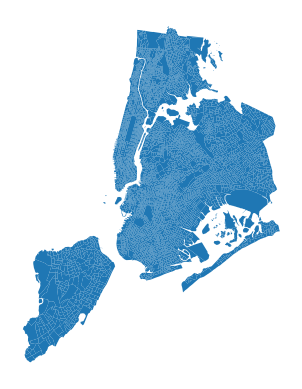

In [25]:
print(census_nyc.shape)
census_nyc.plot().set_axis_off()

Finally before saving, let's change the coordinate reference system to EPSG:2263, which is the standard coordinate reference system for New York State Plane. This will make it easier to work with other NYC Open Data products later on.

In [26]:
census_nyc_sp = census_nyc.to_crs(epsg=2263)

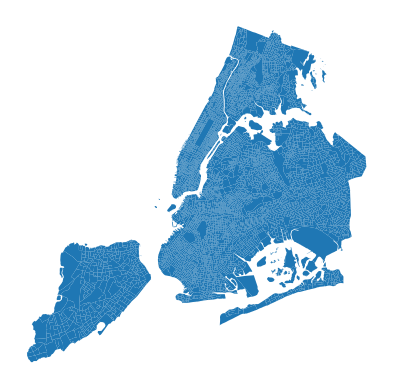

In [27]:
census_nyc_sp.plot().set_axis_off()

In [28]:
census_nyc_sp.to_file("./Data/census_nyc_sp.fgb")